# Обработка фото рисунка

In [1]:
%load_ext autoreload
%autoreload 2

import json
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.spatial import Delaunay
from PIL import Image
from utils import detect_and_align, alignment_error, extract_colored, transfer_color, template_meta

# --- конфиг ---
PHOTO_PATH = "input/img04_photo.jpg"
IMG_PATH = "input/img04.png"
SKELETON_JSON = "output/img04_skeleton.json"
CONTENT_SCALE = 0.8

CANVAS_SIZE = (1240, 1754)
MARKER_PX = 80
MARGIN = 60
CONTENT_PAD = 10

meta = template_meta(CANVAS_SIZE, MARKER_PX, MARGIN, CONTENT_PAD)

## Шаг 1. Выравнивание по ArUco

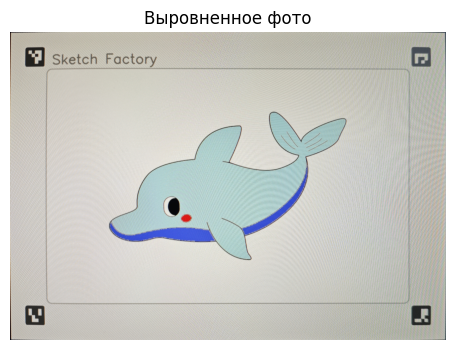

In [2]:
result = detect_and_align(PHOTO_PATH, meta)
aligned = result["aligned"]

plt.figure(figsize=(7, 4))
plt.imshow(cv2.cvtColor(aligned, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Выровненное фото")
plt.show()

In [3]:
mean_err, errors = alignment_error(aligned, meta)
print(f"Средняя ошибка: {mean_err:.2f} px")
if mean_err < 1:
    print("Отлично!")
elif mean_err < 3:
    print("Нормально")
else:
    print("Плохо — лучше переснять")


Средняя ошибка: 4.73 px
Плохо — лучше переснять


## Шаг 3. Вырезка рисунка


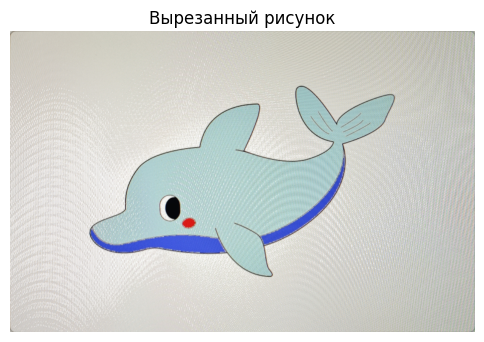

In [4]:
extracted = extract_colored(aligned, meta)

plt.figure(figsize=(6, 4))
plt.imshow(cv2.cvtColor(extracted["rgba"], cv2.COLOR_BGRA2RGBA))
plt.axis("off")
plt.title("Вырезанный рисунок")
plt.show()

## Шаг 4. Перенос цвета на оригинал

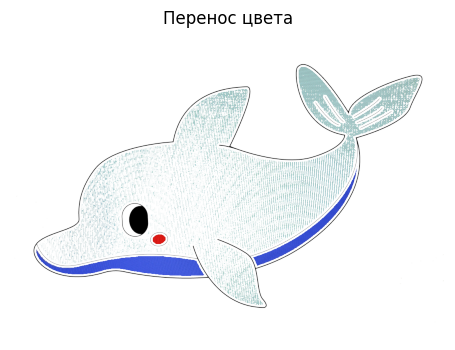

In [5]:
# пересчитываем image_rect (та же логика что в overlay_character)
original = cv2.imread(IMG_PATH, cv2.IMREAD_UNCHANGED)
ih, iw = original.shape[:2]
bx, by, bw, bh = meta["drawing_bbox"]
scale = min(bw / iw, bh / ih) * CONTENT_SCALE
tw, th = int(iw * scale), int(ih * scale)
x0 = bx + (bw - tw) // 2
y0 = by + (bh - th) // 2
image_rect = [x0, y0, tw, th]

colored = transfer_color(aligned, IMG_PATH, image_rect)

plt.figure(figsize=(6, 4))
plt.imshow(cv2.cvtColor(colored["rgba"], cv2.COLOR_BGRA2RGBA))
plt.axis("off")
plt.title("Перенос цвета")
plt.show()

In [6]:
import cv2
import numpy as np

mask = cv2.imread("input/mask04.png", cv2.IMREAD_GRAYSCALE)
unique, counts = np.unique(mask, return_counts=True)

print(f"Размер маски: {mask.shape}")
print(f"\nУникальных значений: {len(unique)}")
print(f"{'Значение':>10} {'Пикселей':>10} {'Доля %':>8}")
print("-" * 30)
for v, c in zip(unique, counts):
    print(f"{v:>10} {c:>10} {c / mask.size * 100:>7.1f}%")


Размер маски: (595, 842)

Уникальных значений: 3
  Значение   Пикселей   Доля %
------------------------------
         0      12346     2.5%
       128     342801    68.4%
       255     145843    29.1%


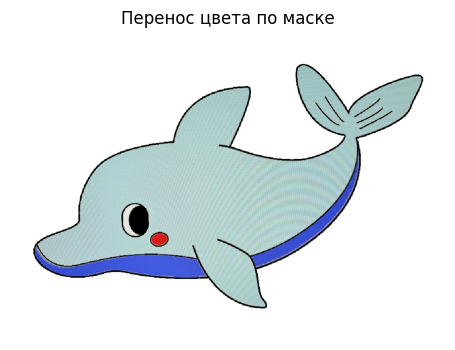

In [9]:
# image_rect (на случай если ячейка шага 4 не запускалась)
original = cv2.imread(IMG_PATH, cv2.IMREAD_UNCHANGED)
oh, ow = original.shape[:2]
bx, by, bw, bh = meta["drawing_bbox"]
scale = min(bw / ow, bh / oh) * CONTENT_SCALE
iw, ih = int(ow * scale), int(oh * scale)
ix = bx + (bw - iw) // 2
iy = by + (bh - ih) // 2

# маска
mask = cv2.imread("input/mask04.png", cv2.IMREAD_GRAYSCALE)
mask = cv2.resize(mask, (iw, ih), interpolation=cv2.INTER_NEAREST)

contour = mask < 50
fill = mask > 200
between = ~contour & ~fill  # промежуточные значения

photo_crop = aligned[iy : iy + ih, ix : ix + iw]

result = np.zeros((ih, iw, 4), dtype=np.uint8)
result[contour] = [0, 0, 0, 255]           # чёрные контуры
result[fill, :3] = photo_crop[fill]         # цвет с фото
result[fill, 3] = 255
result[between] = [255, 255, 255, 255]      # промежуточное → белый

plt.figure(figsize=(6, 4))
plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGRA2RGBA))
plt.axis("off")
plt.title("Перенос цвета по маске")
plt.show()

## Шаг 5. Скелет + триангуляция

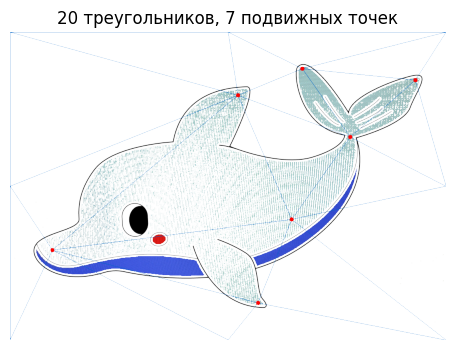

In [13]:
with open(SKELETON_JSON, encoding="utf-8") as f:
    skel_data = json.load(f)

SKELETON = skel_data["skeleton"]
keypoints = skel_data["keypoints"]

# абсолютные координаты скелета на вырезанном персонаже
skel_pts = np.array([[kp[0] * tw, kp[1] * th] for kp in keypoints.values()], dtype=np.float32)

# якорные точки (углы + серединки)
corners = [
    [0, 0], [tw, 0], [tw, th], [0, th],
    [tw//2, 0], [tw, th//2], [tw//2, th], [0, th//2],
]
ctrl_pts = np.vstack([skel_pts, np.array(corners, dtype=np.float32)])
n_kp = len(SKELETON["points"])

tri = Delaunay(ctrl_pts)

# визуализация
img_rgba = colored["rgba"].copy()
vis = img_rgba.copy()
for simplex in tri.simplices:
    pts = ctrl_pts[simplex].astype(np.int32)
    cv2.polylines(vis, [pts], True, (200, 100, 0, 255), 1)
for i, pt in enumerate(skel_pts):
    cv2.circle(vis, pt.astype(int).tolist(), 5, (0, 0, 255, 255), -1)

plt.figure(figsize=(6, 4))
plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGRA2RGBA))
plt.axis("off")
plt.title(f"{len(tri.simplices)} треугольников, {n_kp} подвижных точек")
plt.show()


## Шаг 6. Анимация

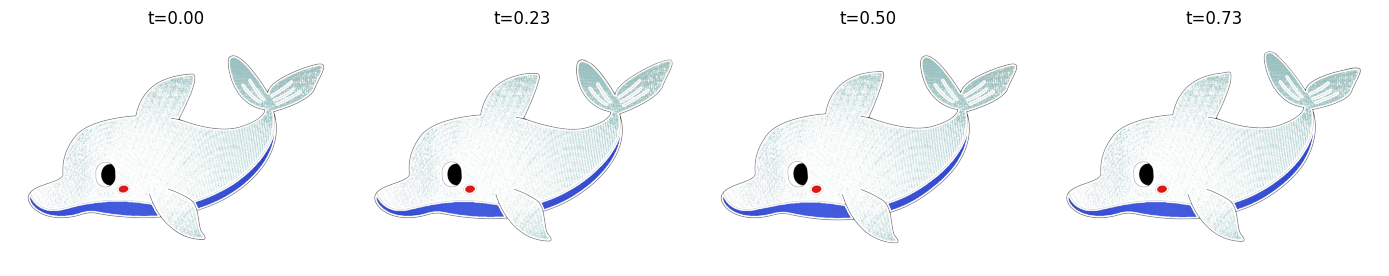

Сохранено: output/img04_result.gif (30 кадров, 2s)


In [15]:
FPS = 15
DURATION = 2

def make_motion(t, base_pts, n_kp, names):
    pts = base_pts.copy()
    a = t * 2 * np.pi
    idx = {name: i for i, name in enumerate(names)}

    if "tail_base" in idx:
        pts[idx["tail_base"], 1] += np.sin(a) * 8
    if "tail_tip1" in idx:
        pts[idx["tail_tip1"], 0] += np.sin(a) * 10
        pts[idx["tail_tip1"], 1] += np.sin(a) * 15
    if "tail_tip2" in idx:
        pts[idx["tail_tip2"], 0] += np.sin(a) * 10
        pts[idx["tail_tip2"], 1] -= np.sin(a) * 15
    if "top_fin" in idx:
        pts[idx["top_fin"], 0] += np.sin(a + np.pi*0.5) * 8
        pts[idx["top_fin"], 1] += np.sin(a + np.pi*0.5) * 5
    if "bottom_fin" in idx:
        pts[idx["bottom_fin"], 1] += np.sin(a - np.pi*0.5) * 6
    if "nose" in idx:
        pts[idx["nose"], 0] += np.sin(a) * 3
    return pts


def warp_triangle(src_img, src_tri, dst_tri, dst_img):
    r = cv2.boundingRect(np.float32([dst_tri]))
    x, y, w, h = r
    if w <= 0 or h <= 0:
        return
    x2 = min(x + w, dst_img.shape[1])
    y2 = min(y + h, dst_img.shape[0])
    x, y = max(x, 0), max(y, 0)
    w, h = x2 - x, y2 - y
    if w <= 0 or h <= 0:
        return
    dst_local = np.float32([(p[0]-x, p[1]-y) for p in dst_tri])
    M = cv2.getAffineTransform(np.float32(src_tri), dst_local)
    warped = cv2.warpAffine(src_img, M, (w, h), flags=cv2.INTER_LINEAR,
                            borderMode=cv2.BORDER_REFLECT_101)
    mask = np.zeros((h, w), dtype=np.uint8)
    cv2.fillConvexPoly(mask, np.int32(dst_local), 255)
    roi = dst_img[y:y2, x:x2]
    m = mask[:roi.shape[0], :roi.shape[1]] > 0
    warped = warped[:roi.shape[0], :roi.shape[1]]
    for c in range(dst_img.shape[2]):
        roi[:, :, c] = np.where(m, warped[:, :, c], roi[:, :, c])


n_frames = FPS * DURATION
frames = []
for i in range(n_frames):
    t = i / n_frames
    dst_pts = make_motion(t, ctrl_pts, n_kp, SKELETON["points"])
    dst_img = np.zeros_like(img_rgba)
    for simplex in tri.simplices:
        warp_triangle(img_rgba, ctrl_pts[simplex].tolist(),
                      dst_pts[simplex].tolist(), dst_img)
    frames.append(dst_img)

# превью
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for ax, fi in zip(axes, [0, n_frames//4, n_frames//2, 3*n_frames//4]):
    ax.imshow(cv2.cvtColor(frames[fi], cv2.COLOR_BGRA2RGBA))
    ax.set_title(f"t={fi/n_frames:.2f}")
    ax.axis("off")
plt.tight_layout()
plt.show()

# GIF
out_gif = f"output/{Path(IMG_PATH).stem}_result.gif"
pil_frames = [Image.fromarray(cv2.cvtColor(f, cv2.COLOR_BGRA2RGBA)) for f in frames]
pil_frames[0].save(out_gif, save_all=True, append_images=pil_frames[1:],
                   duration=1000//FPS, loop=0, disposal=2)
print(f"Сохранено: {out_gif} ({n_frames} кадров, {DURATION}s)")

In [17]:
def make_wave_flip_frames(img, n_frames=40):
    h, w = img.shape[:2]
    flip_frames = []
    for i in range(n_frames):
        t = i / (n_frames - 1)
        result = np.zeros_like(img)
        for col in range(w):
            delay = (col / w) * 0.6  # слева направо
            local_t = (t - delay) / (1 - 0.6)
            local_t = np.clip(local_t, 0, 1)
            angle = local_t * np.pi
            scale_y = abs(np.cos(angle))
            if scale_y < 0.01:
                continue
            cy = h / 2
            for dst_y in range(h):
                src_y = int(cy + (dst_y - cy) / scale_y)
                if 0 <= src_y < h:
                    result[dst_y, col] = img[src_y, col]
        flip_frames.append(result)
    return flip_frames

flip = make_wave_flip_frames(frames[-1], n_frames=40)
all_frames = frames + flip[1:]  # [1:] убирает дубликат последнего кадра

out_gif = f"output/{Path(IMG_PATH).stem}_result.gif"
pil_frames = [Image.fromarray(cv2.cvtColor(f, cv2.COLOR_BGRA2RGBA)) for f in all_frames]
pil_frames[0].save(out_gif, save_all=True, append_images=pil_frames[1:],
                   duration=1000//FPS, loop=0, disposal=2)
print(f"Сохранено: {out_gif} ({len(all_frames)} кадров)")

Сохранено: output/img04_result.gif (69 кадров)


# _OLD

In [ ]:
%load_ext autoreload
%autoreload 2

import cv2
import matplotlib.pyplot as plt
from pathlib import Path
from utils import detect_and_align, alignment_error, template_meta

# те же параметры что в prepare_template.ipynb
CANVAS_SIZE = (1240, 1754)
MARKER_PX = 80
MARGIN = 60
CONTENT_PAD = 10

META = template_meta(CANVAS_SIZE, MARKER_PX, MARGIN, CONTENT_PAD)
OUTPUT_DIR = "output"

In [ ]:
def show_alignment(photo_path, save=True):
    """Выровнять фото и показать результат."""
    photo = cv2.imread(photo_path)
    res = detect_and_align(photo_path, META)
    err, _ = alignment_error(res["aligned"], META, MARKER_PX, MARGIN)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    axes[0].imshow(cv2.cvtColor(photo, cv2.COLOR_BGR2RGB))
    axes[0].set_title(Path(photo_path).stem)
    axes[1].imshow(cv2.cvtColor(res["aligned"], cv2.COLOR_BGR2RGB))
    axes[1].set_title(f"Выровненное — ошибка {err:.1f} px")
    for ax in axes:
        ax.axis("off")
    plt.tight_layout()
    plt.show()

    if save:
        out = f"{OUTPUT_DIR}/{Path(photo_path).stem}_aligned.jpg"
        cv2.imwrite(out, res["aligned"])
        print(f"Сохранено: {out}")

In [ ]:
show_alignment("input/img01_photo.jpg")
show_alignment("input/img01_photo_bad.jpg")
show_alignment("input/img03_photo.jpg")
show_alignment("input/img03_photo_bad.jpg")
show_alignment("input/img04_photo.jpg")
show_alignment("input/img04_photo_bad.jpg")